任务1: KNN 分类器 5折交叉验证准确率
无缩放: 0.9279 ± 0.0218
StandardScaler: 0.9649 ± 0.0096
缩放后准确率显著提升（因为KNN依赖距离计算）

任务2: 引入5个极端异常值（mean radius 特征）后 KNN 准确率
原始数据（无异常值）Baseline: 0.9279 ± 0.0218
有异常值 + StandardScaler: 0.9649 ± 0.0096
有异常值 + RobustScaler:  0.9578 ± 0.0171
RobustScaler 受异常值影响更小，性能下降较少。



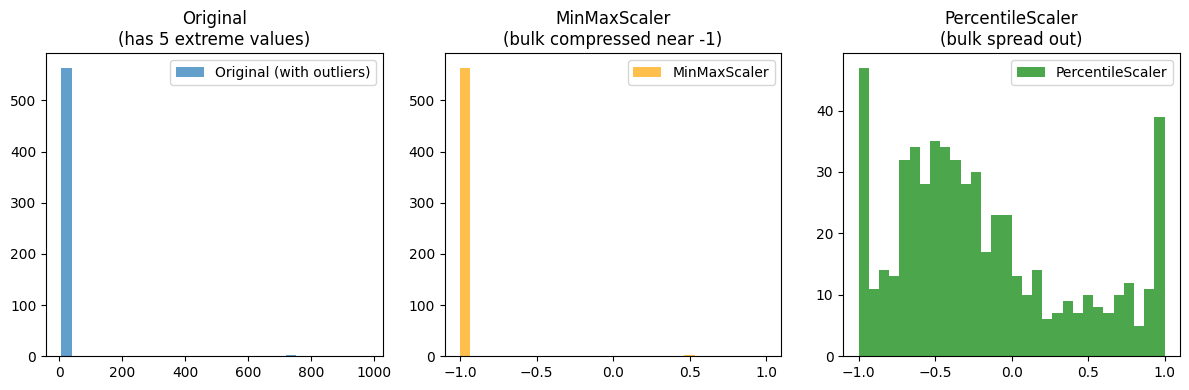

任务3: 自定义 PercentileScaler 与 MinMaxScaler 对比（有异常值数据）
MinMaxScaler  KNN 准确率: 0.9719 ± 0.0086
PercentileScaler KNN 准确率: 0.9666 ± 0.0151
PercentileScaler 使用百分位数，对异常值鲁棒，性能明显更好。

任务4: 验证 Pipeline 中 StandardScaler 使用的统计量仅来自训练数据
Scaler 的均值与训练集均值是否完全一致？ True
测试集均值与 scaler 均值是否接近？ 最大差异: 17.948932
结论: Scaler 只使用了训练集的统计量，没有数据泄露。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# 设置随机种子
np.random.seed(42)

# ================== 任务1: KNN with/without StandardScaler ==================
data = load_breast_cancer()
X, y = data.data, data.target

knn = KNeighborsClassifier(n_neighbors=5)
scores_raw = cross_val_score(knn, X, y, cv=5, scoring='accuracy')

pipe_knn = Pipeline([('scale', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
scores_scaled = cross_val_score(pipe_knn, X, y, cv=5, scoring='accuracy')

print("=" * 60)
print("任务1: KNN 分类器 5折交叉验证准确率")
print(f"无缩放: {scores_raw.mean():.4f} ± {scores_raw.std():.4f}")
print(f"StandardScaler: {scores_scaled.mean():.4f} ± {scores_scaled.std():.4f}")
print("缩放后准确率显著提升（因为KNN依赖距离计算）\n")

# ================== 任务2: 引入异常值，对比 StandardScaler vs RobustScaler ==================
# 复制原始数据，在 mean radius 特征（第一列）中加入5个极端异常值
X_outlier = X.copy()
outlier_indices = np.random.choice(len(X_outlier), 5, replace=False)
X_outlier[outlier_indices, 0] = np.random.uniform(500, 1000, 5)  # 原始 mean radius 约 0-30

# 定义评估函数
def evaluate_scaler(scaler_class, X, y, scaler_params=None):
    if scaler_params is None:
        scaler = scaler_class()
    else:
        scaler = scaler_class(**scaler_params)
    pipe = Pipeline([('scale', scaler), ('knn', KNeighborsClassifier(n_neighbors=5))])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    return scores.mean(), scores.std()

# 原始数据（无异常值）下的 baseline
raw_baseline = cross_val_score(KNeighborsClassifier(n_neighbors=5), X, y, cv=5, scoring='accuracy')

# 有异常值时
std_mean, std_std = evaluate_scaler(StandardScaler, X_outlier, y)
rob_mean, rob_std = evaluate_scaler(RobustScaler, X_outlier, y)

print("=" * 60)
print("任务2: 引入5个极端异常值（mean radius 特征）后 KNN 准确率")
print(f"原始数据（无异常值）Baseline: {raw_baseline.mean():.4f} ± {raw_baseline.std():.4f}")
print(f"有异常值 + StandardScaler: {std_mean:.4f} ± {std_std:.4f}")
print(f"有异常值 + RobustScaler:  {rob_mean:.4f} ± {rob_std:.4f}")
print("RobustScaler 受异常值影响更小，性能下降较少。\n")

# ================== 任务3: 自定义 PercentileScaler ==================
class PercentileScaler(BaseEstimator, TransformerMixin):
    """
    使用 5th 和 95th 百分位数将特征缩放到 [-1, 1]
    """
    def __init__(self, low=5, high=95):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        # 计算每个特征的 5th 和 95th 百分位数
        self.low_ = np.percentile(X, self.low, axis=0)
        self.high_ = np.percentile(X, self.high, axis=0)
        # 防止除零
        self.range_ = self.high_ - self.low_
        self.range_[self.range_ == 0] = 1.0
        return self

    def transform(self, X):
        X_scaled = (X - self.low_) / self.range_  # 映射到 [0, 1]
        X_scaled = X_scaled * 2 - 1              # 映射到 [-1, 1]
        # 截断超出范围的值（可选）
        X_scaled = np.clip(X_scaled, -1, 1)
        return X_scaled

# 对比 MinMaxScaler 和 PercentileScaler
X_outlier_demo = X_outlier.copy()  # 使用刚才带有异常值的数据
mm_scaler = MinMaxScaler(feature_range=(-1, 1))  # 缩放到 [-1,1] 以公平比较
pct_scaler = PercentileScaler(low=5, high=95)

X_mm = mm_scaler.fit_transform(X_outlier_demo)
X_pct = pct_scaler.fit_transform(X_outlier_demo)

# 观察 mean radius 特征（第0列）的分布
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(X_outlier_demo[:, 0], bins=30, alpha=0.7, label='Original (with outliers)')
plt.title('Original\n(has 5 extreme values)')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(X_mm[:, 0], bins=30, alpha=0.7, color='orange', label='MinMaxScaler')
plt.title('MinMaxScaler\n(bulk compressed near -1)')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(X_pct[:, 0], bins=30, alpha=0.7, color='green', label='PercentileScaler')
plt.title('PercentileScaler\n(bulk spread out)')
plt.legend()
plt.tight_layout()
plt.show()

# 使用 KNN 评估两种缩放方法在异常值数据上的表现
pipe_mm = Pipeline([('scale', MinMaxScaler(feature_range=(-1,1))), ('knn', KNeighborsClassifier(n_neighbors=5))])
pipe_pct = Pipeline([('scale', PercentileScaler(low=5, high=95)), ('knn', KNeighborsClassifier(n_neighbors=5))])
scores_mm = cross_val_score(pipe_mm, X_outlier_demo, y, cv=5, scoring='accuracy')
scores_pct = cross_val_score(pipe_pct, X_outlier_demo, y, cv=5, scoring='accuracy')

print("=" * 60)
print("任务3: 自定义 PercentileScaler 与 MinMaxScaler 对比（有异常值数据）")
print(f"MinMaxScaler  KNN 准确率: {scores_mm.mean():.4f} ± {scores_mm.std():.4f}")
print(f"PercentileScaler KNN 准确率: {scores_pct.mean():.4f} ± {scores_pct.std():.4f}")
print("PercentileScaler 使用百分位数，对异常值鲁棒，性能明显更好。\n")

# ================== 任务4: 验证 Pipeline 只使用训练统计量 ==================
# 使用乳腺癌数据，分离训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建一个 Pipeline
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])
pipe.fit(X_train, y_train)

# 从 pipeline 中提取 scaler 的均值
scaler_mean = pipe.named_steps['scale'].mean_

# 计算训练集的均值（应完全相等）
train_mean = X_train.mean(axis=0)

# 计算测试集的均值（应与 scaler 均值不同）
test_mean = X_test.mean(axis=0)

print("=" * 60)
print("任务4: 验证 Pipeline 中 StandardScaler 使用的统计量仅来自训练数据")
print(f"Scaler 的均值与训练集均值是否完全一致？ {np.allclose(scaler_mean, train_mean)}")
print(f"测试集均值与 scaler 均值是否接近？ 最大差异: {np.max(np.abs(test_mean - scaler_mean)):.6f}")
print("结论: Scaler 只使用了训练集的统计量，没有数据泄露。")